In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df_detached_homes = pd.read_parquet("../detached_home_data.parquet")

type(df_detached_homes)

pandas.core.frame.DataFrame

In [3]:
df_detached_homes.index.names[0]

'Property_ID'

In [4]:
id_name = 'EOH1703'
df_single_property_data = df_detached_homes.loc[id_name]


In [5]:
df_single_property_data.tail()

,Timestamp,Circulation_Pump_Energy_Consumed,External_Air_Temperature,Heat_Pump_Energy_Output,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,Hot_Water_Flow_Temperature,Internal_Air_Temperature,Whole_System_Energy_Consumed,Boiler_Energy_Output,Immersion_Heater_Energy_Consumed,Brine_Flow_Temperature,Brine_Return_Temperature,Back-up_Heater_Energy_Consumed,Unnamed: 0
Timestamp,,,,,,,,,,,,,,,
2023-09-28 23:50:00,2023-09-28 23:50:00,NaN,12.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2023-09-28 23:52:00,2023-09-28 23:52:00,NaN,12.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2023-09-28 23:54:00,2023-09-28 23:54:00,NaN,12.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2023-09-28 23:56:00,2023-09-28 23:56:00,NaN,12.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2023-09-28 23:58:00,2023-09-28 23:58:00,NaN,12.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [6]:
df_temps_high = df_single_property_data[df_single_property_data
                                        ["External_Air_Temperature"]>23]

DatetimeIndex(['2021-07-17 09:52:00', '2021-07-17 09:54:00',
               '2021-07-17 09:56:00', '2021-07-17 09:58:00',
               '2021-07-17 10:00:00', '2021-07-17 10:02:00',
               '2021-07-17 10:04:00', '2021-07-17 10:06:00',
               '2021-07-17 10:08:00', '2021-07-17 10:10:00',
               ...
               '2023-09-10 12:04:00', '2023-09-10 12:06:00',
               '2023-09-10 12:08:00', '2023-09-10 12:10:00',
               '2023-09-10 12:12:00', '2023-09-10 12:14:00',
               '2023-09-10 12:16:00', '2023-09-10 12:18:00',
               '2023-09-10 12:20:00', '2023-09-10 12:22:00'],
              dtype='datetime64[ns]', name='Timestamp', length=5606, freq=None)

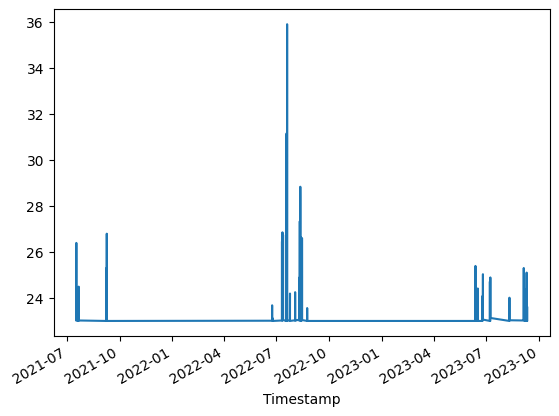

In [7]:
df_temps_high["External_Air_Temperature"].plot()
df_temps_high.index


In [22]:
#Isolate water usage
t_start = pd.to_datetime("2022-08-01")
t_end = pd.to_datetime("2022-08-20")

df_isolate = df_single_property_data[df_single_property_data.index >= t_start]
df_isolate = df_isolate[df_isolate.index <= t_end]
df_isolate.tail()

,Timestamp,Circulation_Pump_Energy_Consumed,External_Air_Temperature,Heat_Pump_Energy_Output,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,Hot_Water_Flow_Temperature,Internal_Air_Temperature,Whole_System_Energy_Consumed,Boiler_Energy_Output,Immersion_Heater_Energy_Consumed,Brine_Flow_Temperature,Brine_Return_Temperature,Back-up_Heater_Energy_Consumed,Unnamed: 0
Timestamp,,,,,,,,,,,,,,,
2022-08-19 23:52:00,2022-08-19 23:52:00,289.45,10.45,22729.22,28.62,28.04,NaN,22.18,8476.333,NaN,212.224,NaN,NaN,203.525,None
2022-08-19 23:54:00,2022-08-19 23:54:00,289.45,10.40,22729.22,28.58,28.06,NaN,22.18,8476.334,NaN,212.224,NaN,NaN,203.525,None
2022-08-19 23:56:00,2022-08-19 23:56:00,289.45,10.36,22729.22,28.55,28.10,NaN,22.18,8476.334,NaN,212.224,NaN,NaN,203.525,None
2022-08-19 23:58:00,2022-08-19 23:58:00,289.45,10.31,22729.22,28.52,27.95,NaN,22.18,8476.335,NaN,212.224,NaN,NaN,203.525,None
2022-08-20 00:00:00,2022-08-20 00:00:00,289.45,10.27,22729.22,28.47,27.91,NaN,22.18,8476.335,NaN,212.224,NaN,NaN,203.525,None


<Axes: xlabel='Timestamp'>

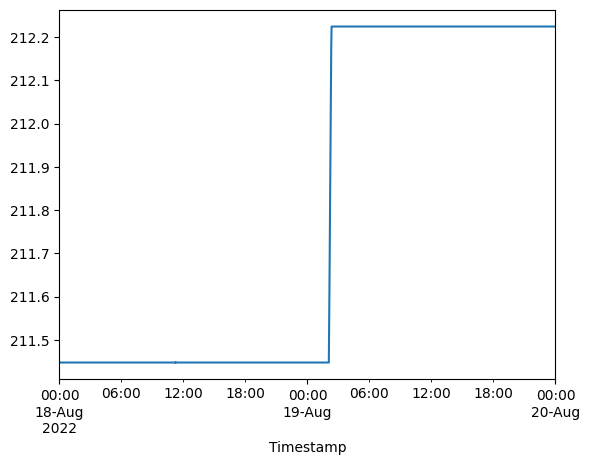

In [16]:
df_isolate["Immersion_Heater_Energy_Consumed"].plot()

In [23]:
#df_isolate["External_Air_Temperature"].plot()
circ_pump = df_isolate["Circulation_Pump_Energy_Consumed"].diff()
q_hp = df_isolate["Heat_Pump_Energy_Output"].diff()
q_immersion = df_isolate["Immersion_Heater_Energy_Consumed"].diff().fillna(0)
q_back_up = df_isolate["Back-up_Heater_Energy_Consumed"].diff().fillna(0)
q_boiler = df_isolate["Boiler_Energy_Output"].diff().fillna(0)
T_a = df_isolate["External_Air_Temperature"]
T_hp_flow = df_isolate["Heat_Pump_Heating_Flow_Temperature"]
T_hp_return = df_isolate["Heat_Pump_Return_Temperature"]
T_hw = df_isolate["Hot_Water_Flow_Temperature"]
T_i = df_isolate["Internal_Air_Temperature"]

m_dot = q_hp / ((T_hp_flow-T_hp_return)*4.184)
q_total = q_hp+q_immersion+q_back_up+q_boiler

<Axes: xlabel='Timestamp'>

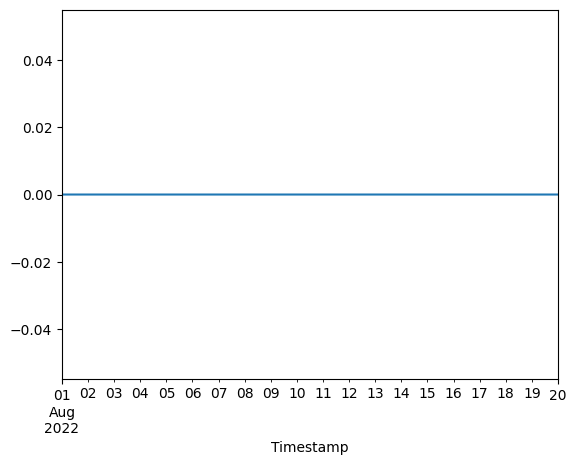

In [24]:
q_back_up.plot()

<Axes: xlabel='Timestamp'>

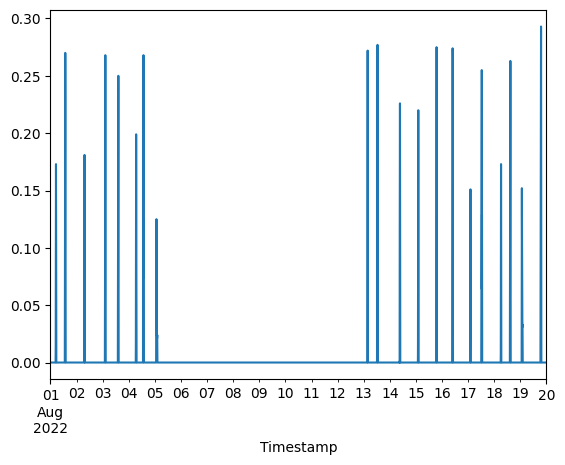

In [25]:
#Find when T_hw is active. Delete q_hp during this time and creat q_sc

q_hp_sc = q_hp.where(T_hw.isnull(),0)
q_sc = q_total.where(T_hw.isnull(),0)
q_DHW = q_hp.where(T_hw.notnull(), 0)
q_DHW.plot()
#q_DHW

In [26]:
q_hp_sc_half_hour = q_sc.resample('30min').sum()
q_sc_half_hour = q_sc.resample('30min').sum()
T_a_half_hour = T_a.resample('30min').mean()
T_i_half_hour = T_i.resample('30min').mean()


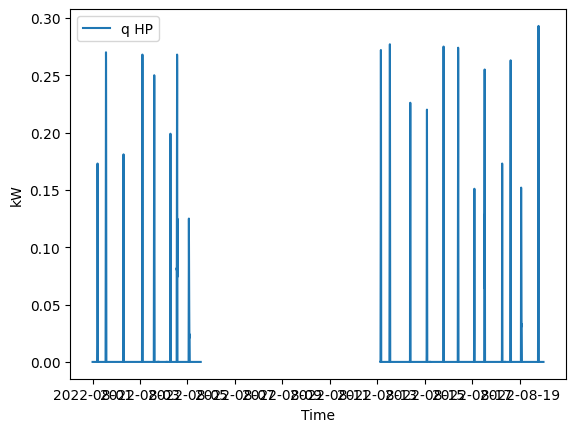

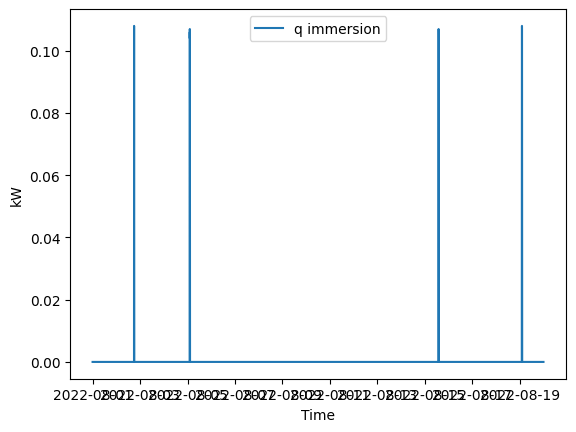

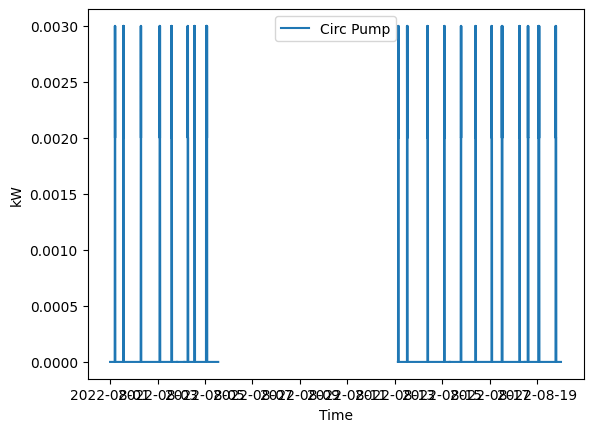

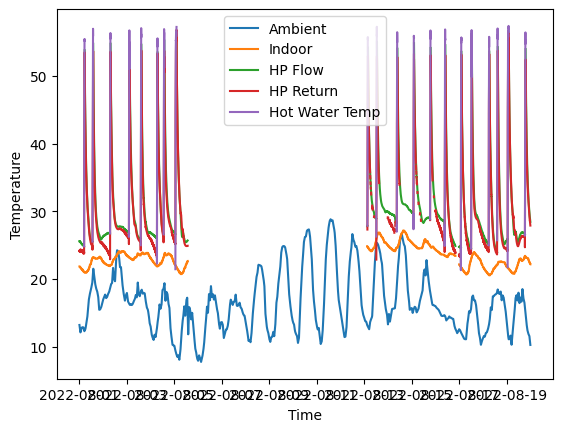

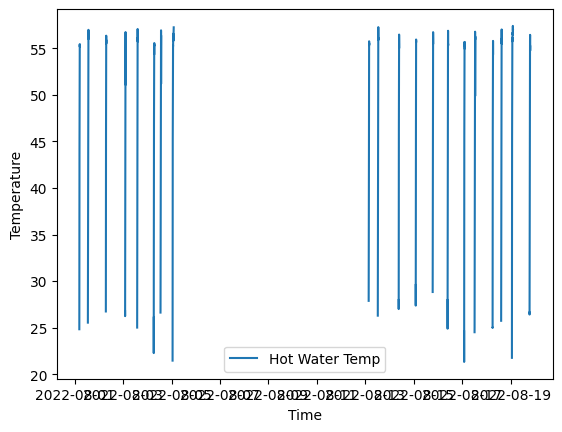

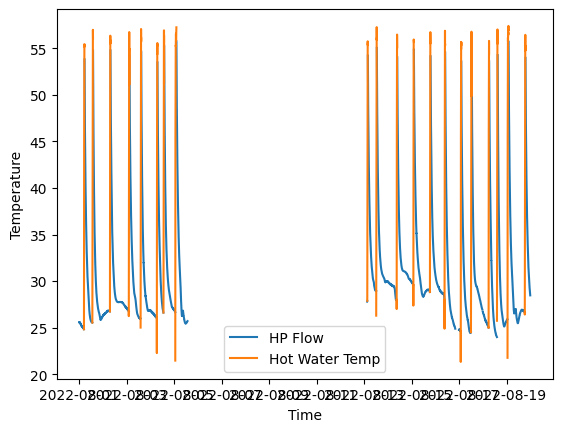

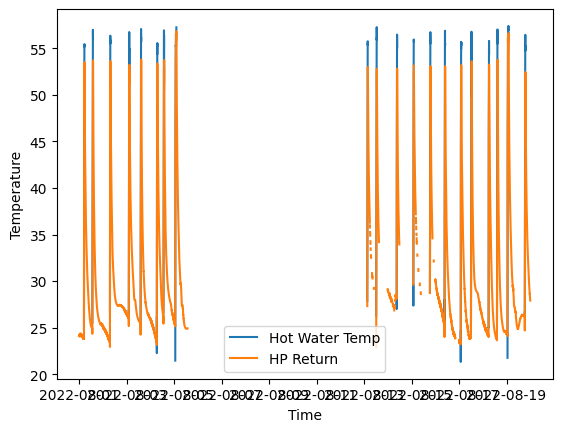

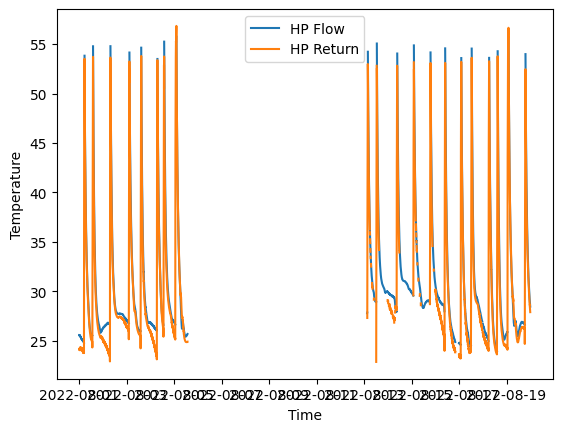

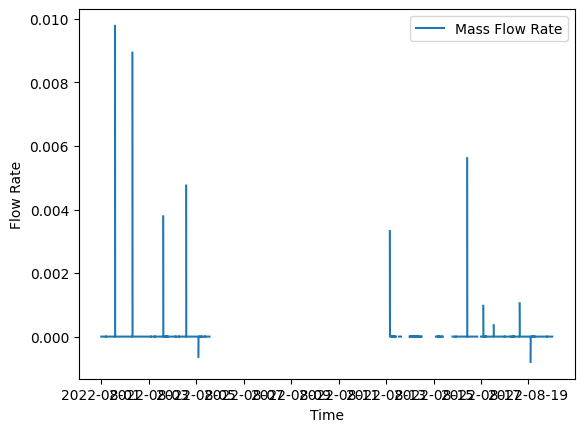

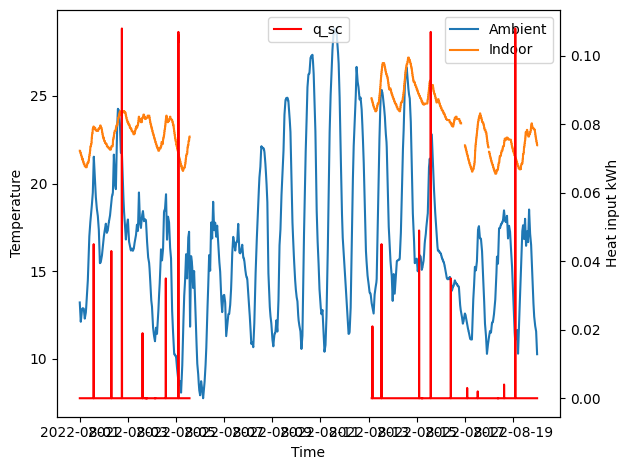

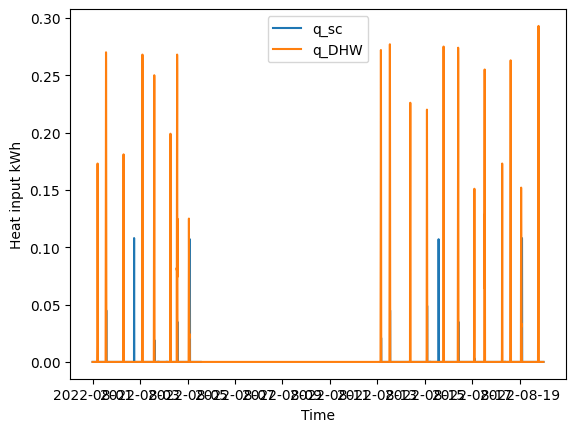

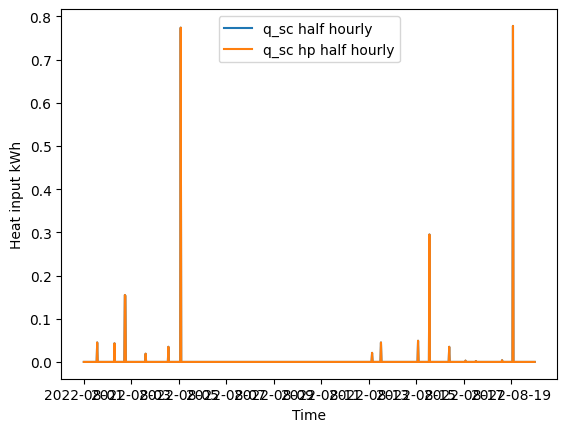

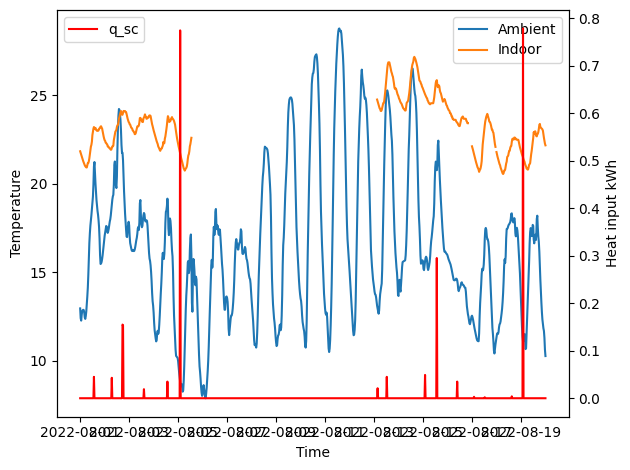

In [27]:
plt.plot(q_hp, label ="q HP")
plt.xlabel("Time")
plt.ylabel("kW")
plt.legend()
plt.show()

plt.plot(q_immersion, label ="q immersion")
plt.xlabel("Time")
plt.ylabel("kW")
plt.legend()
plt.show()

plt.plot(circ_pump,label ="Circ Pump")
plt.xlabel("Time")
plt.ylabel("kW")
plt.legend()
plt.show()

plt.plot(T_a,label ="Ambient")
plt.plot(T_i, label ="Indoor")
plt.plot(T_hp_flow, label = "HP Flow")
plt.plot(T_hp_return, label = "HP Return")
plt.plot(T_hw, label ="Hot Water Temp")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

plt.plot(T_hw, label ="Hot Water Temp")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

plt.plot(T_hp_flow, label = "HP Flow")
plt.plot(T_hw, label ="Hot Water Temp")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

plt.plot(T_hw, label ="Hot Water Temp")
plt.plot(T_hp_return, label = "HP Return")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

plt.plot(T_hp_flow, label = "HP Flow")
plt.plot(T_hp_return, label = "HP Return")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()


plt.plot(m_dot, label = "Mass Flow Rate")
plt.xlabel("Time")
plt.ylabel("Flow Rate")
plt.legend()
plt.show()



fig,ax1 = plt.subplots()
ax1.plot(T_a,label ="Ambient")
ax1.plot(T_i, label ="Indoor")
ax1.set_ylabel("Temperature")
ax1.set_xlabel("Time")
plt.legend()

ax2 = ax1.twinx()
ax2.plot(q_sc, label = "q_sc", color = "red")
ax2.set_ylabel("Heat input kWh")

fig.tight_layout()
plt.legend()
plt.show()


plt.plot(q_sc, label = "q_sc")
plt.plot(q_DHW, label = "q_DHW")
plt.xlabel("Time")
plt.ylabel("Heat input kWh")
plt.legend()
plt.show()

plt.plot(q_sc_half_hour, label = "q_sc half hourly")
plt.plot(q_hp_sc_half_hour, label = "q_sc hp half hourly")
plt.xlabel("Time")
plt.ylabel("Heat input kWh")
plt.legend()
plt.show()

fig,ax1 = plt.subplots()
ax1.plot(T_a_half_hour,label ="Ambient")
ax1.plot(T_i_half_hour,label ="Indoor")
ax1.set_ylabel("Temperature")
ax1.set_xlabel("Time")
plt.legend()

ax2 = ax1.twinx()
ax2.plot(q_sc_half_hour, label = "q_sc", color = "red")
ax2.set_ylabel("Heat input kWh")

fig.tight_layout()
plt.legend()
plt.show()